In [1]:
import tensorflow as tf
import tensorflow_hub as hub

module_handle = "https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1"
detector = hub.load(module_handle).signatures['default']

INFO:tensorflow:Saver not created because there are no variables in the graph to restore


INFO:tensorflow:Saver not created because there are no variables in the graph to restore


In [2]:
img = tf.io.read_file('image.png')
img = tf.image.decode_jpeg(img, channels=3)
converted_img  = tf.image.convert_image_dtype(img, tf.float32)[tf.newaxis, ...]

In [3]:
result = detector(converted_img)

result = {key:value.numpy() for key,value in result.items()}

print("Found %d objects." % len(result["detection_scores"]))
print(result["detection_scores"])
print(result["detection_class_entities"])
print(result["detection_boxes"])

  

Found 100 objects.
[0.8327043  0.7617637  0.74751055 0.7181399  0.6056658  0.56928444
 0.55996215 0.46918797 0.4144506  0.39861366 0.37207225 0.36934698
 0.34315026 0.336462   0.3161638  0.30598727 0.294252   0.259747
 0.23633917 0.21822484 0.21051762 0.20496534 0.20259616 0.19913292
 0.19132535 0.15872693 0.15421954 0.1486926  0.14389578 0.1418868
 0.14181373 0.14155231 0.13282998 0.12978242 0.1279678  0.11606473
 0.10890598 0.10065431 0.09658305 0.09187318 0.09087679 0.09070642
 0.08772623 0.08628053 0.08517966 0.08498196 0.08312231 0.08150814
 0.08094066 0.07635189 0.07615647 0.07581756 0.0727388  0.07220429
 0.07037167 0.06838667 0.06811077 0.06733025 0.06505069 0.06489339
 0.05822047 0.05678028 0.05677492 0.05445763 0.05267209 0.05231775
 0.0515032  0.05030898 0.04738104 0.04720723 0.04710962 0.04710665
 0.04642129 0.0454275  0.04485617 0.04277319 0.0427565  0.04211576
 0.04207825 0.04196333 0.04144692 0.03936208 0.03721365 0.03712849
 0.03557416 0.03550997 0.03468452 0.03425985 0

In [5]:
from PIL import Image, ImageColor, ImageDraw, ImageFont
import numpy as np
import matplotlib.pyplot as plt

def draw_bounding_box_on_image(image,
                               ymin,
                               xmin,
                               ymax,
                               xmax,
                               color,
                               font,
                               thickness=4,
                               display_str_list=()):
  """Adds a bounding box to an image."""
  draw = ImageDraw.Draw(image)
  im_width, im_height = image.size
  (left, right, top, bottom) = (xmin * im_width, xmax * im_width,
                                ymin * im_height, ymax * im_height)
  draw.line([(left, top), (left, bottom), (right, bottom), (right, top),
             (left, top)],
            width=thickness,
            fill=color)

  # If the total height of the display strings added to the top of the bounding
  # box exceeds the top of the image, stack the strings below the bounding box
  # instead of above.
  display_str_heights = [font.getbbox(ds)[3] for ds in display_str_list]
  # Each display_str has a top and bottom margin of 0.05x.
  total_display_str_height = (1 + 2 * 0.05) * sum(display_str_heights)

  if top > total_display_str_height:
    text_bottom = top
  else:
    text_bottom = top + total_display_str_height
  # Reverse list and print from bottom to top.
  for display_str in display_str_list[::-1]:
    bbox = font.getbbox(display_str)
    text_width, text_height = bbox[2], bbox[3]
    margin = np.ceil(0.05 * text_height)
    draw.rectangle([(left, text_bottom - text_height - 2 * margin),
                    (left + text_width, text_bottom)],
                   fill=color)
    draw.text((left + margin, text_bottom - text_height - margin),
              display_str,
              fill="black",
              font=font)
    text_bottom -= text_height - 2 * margin


def draw_boxes(image, boxes, class_names, scores, max_boxes=10, min_score=0.1):
  """Overlay labeled boxes on an image with formatted scores and label names."""
  colors = list(ImageColor.colormap.values())

  try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf",
                              25)
  except IOError:
    print("Font not found, using default font.")
    font = ImageFont.load_default()

  for i in range(min(boxes.shape[0], max_boxes)):
    if scores[i] >= min_score:
      ymin, xmin, ymax, xmax = tuple(boxes[i])
      display_str = "{}: {}%".format(class_names[i].decode("ascii"),
                                     int(100 * scores[i]))
      color = colors[hash(class_names[i]) % len(colors)]
      image_pil = Image.fromarray(np.uint8(image)).convert("RGB")
      draw_bounding_box_on_image(
          image_pil,
          ymin,
          xmin,
          ymax,
          xmax,
          color,
          font,
          display_str_list=[display_str])
      np.copyto(image, np.array(image_pil))
  return image

def display_image(image):
  fig = plt.figure(figsize=(20, 15))
  plt.grid(False)
  plt.imshow(image)
 

Font not found, using default font.


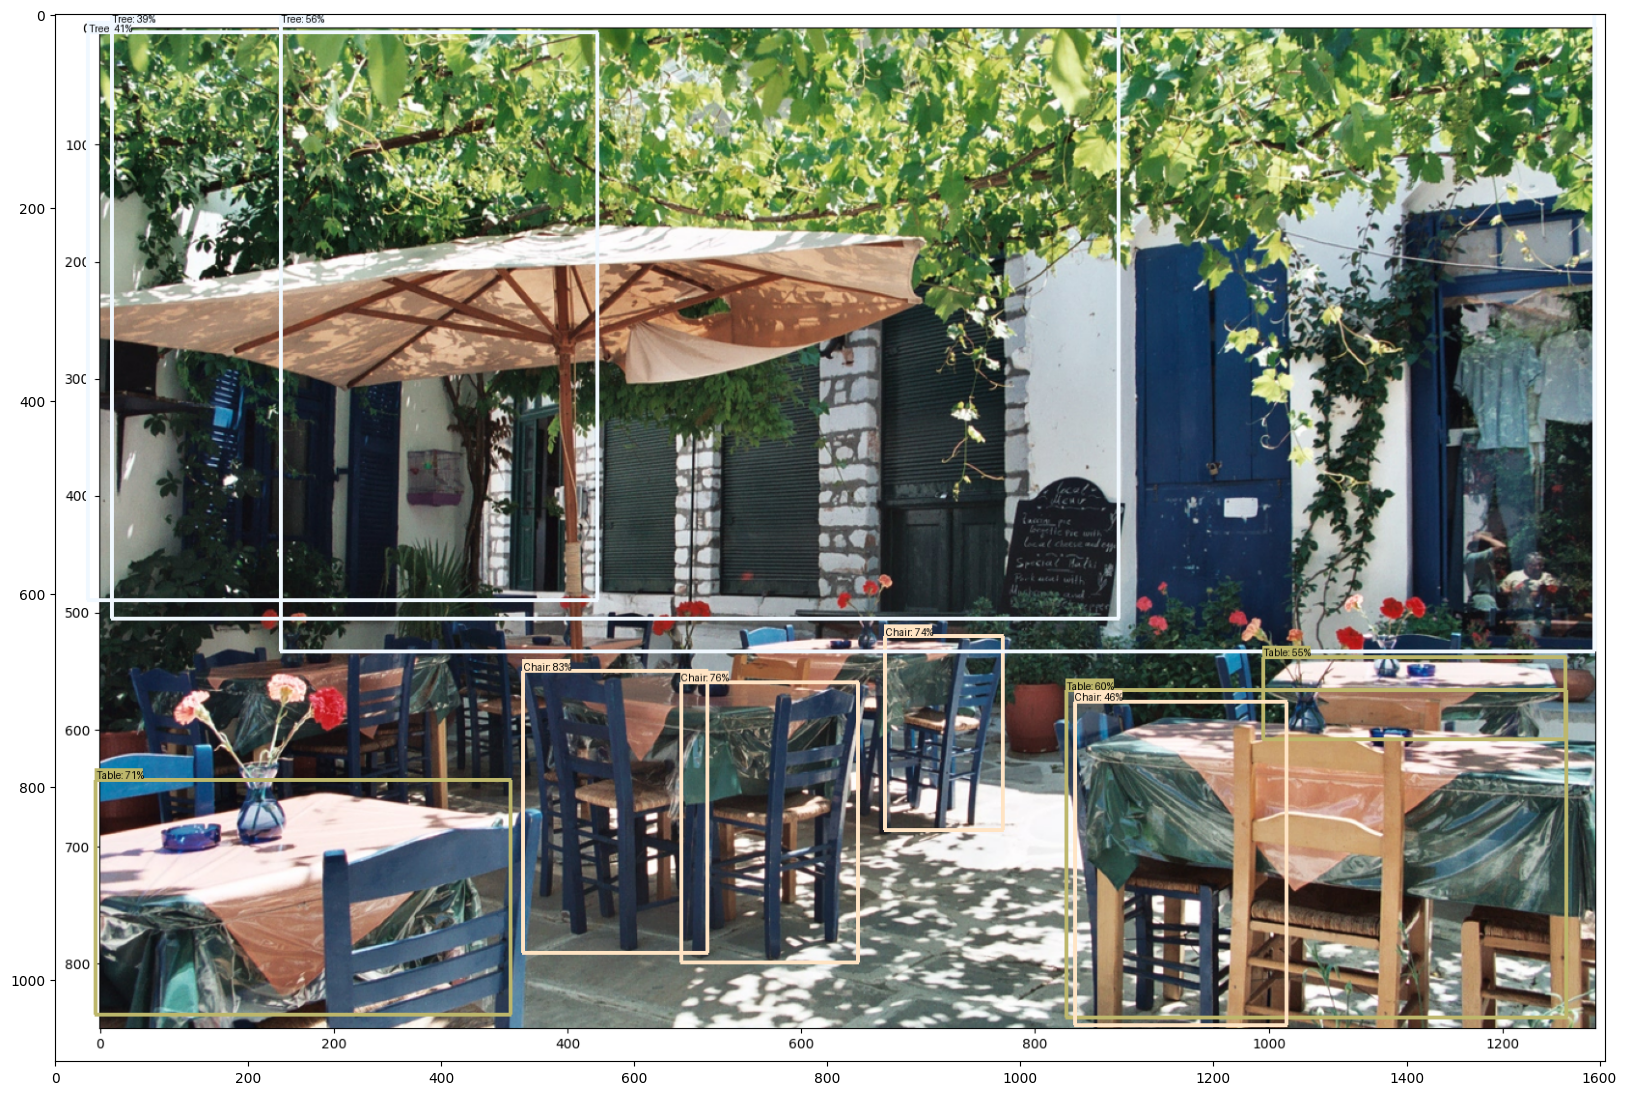

In [6]:
image_with_boxes = draw_boxes(
      img.numpy(), result["detection_boxes"],
      result["detection_class_entities"], result["detection_scores"])

display_image(image_with_boxes)

APIs  -- follow texr file to insatll APIs before running

In [ ]:
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils 
from object_detection.utils import ops as utils_ops

In [ ]:
# Handle models with masks:
image_np_with_mask = ima.copy()

if 'detection_masks' in result:
  # we need to convert np.arrays to tensors
  detection_masks = tf.convert_to_tensor(result['detection_masks'][0])
  detection_boxes = tf.convert_to_tensor(result['detection_boxes'][0])

  # Reframe the bbox mask to the image size.
  detection_masks_reframed = utils_ops.reframe_box_masks_to_image_masks(
            detection_masks, detection_boxes,
              image_np.shape[1], image_np.shape[2])
  detection_masks_reframed = tf.cast(detection_masks_reframed > 0.5,
                                      tf.uint8)
  result['detection_masks_reframed'] = detection_masks_reframed.numpy()

viz_utils.visualize_boxes_and_labels_on_image_array(
      image_np_with_mask[0],
      result['detection_boxes'][0],
      (result['detection_classes'][0] + label_id_offset).astype(int),
      result['detection_scores'][0],
      category_index,
      use_normalized_coordinates=True,
      max_boxes_to_draw=200,
      min_score_thresh=.30,
      agnostic_mode=False,
      instance_masks=result.get('detection_masks_reframed', None),
      line_thickness=8)

plt.figure(figsize=(24,32))
plt.imshow(image_np_with_mask[0])
plt.show()